# Round 3 Manual — Bio-Pods Two-Bid Analysis

Closed-form derivation of the optimal first/second bid pair for the
Celestial Gardeners' Guild manual challenge, with sensitivity over
opponent-average-second-bid assumptions.

See `README.md` for the game mechanics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

LOW, HIGH, STEP = 670, 920, 5
SELL_PRICE = 920
RESERVES = np.arange(LOW, HIGH + STEP, STEP)   # 51 values: 670, 675, ..., 920
N_RESERVES = len(RESERVES)                      # 51
B1_GRID = RESERVES + 1                          # 671, 676, ..., 921 (Pareto-optimal bids)

print(f"reserves: {N_RESERVES} grid points from {RESERVES[0]} to {RESERVES[-1]}")
print(f"bid grid: {len(B1_GRID)} points from {B1_GRID[0]} to {B1_GRID[-1]}")

reserves: 51 grid points from 670 to 920
bid grid: 51 points from 671 to 921


## Stage I — closed-form analytical optimum

If we only submit ONE bid `b1`, expected profit per NPC is

$$ E[\text{profit per NPC}] = \frac{k_1}{51}(920 - b_1), \quad k_1 = \#\{r \in \text{grid} : r < b_1\} $$

Within each "tier" (same `k_1`), bidding higher only burns money. So optimal `b1` sits one above a grid point: `b1 ∈ {671, 676, ..., 921}`.

For `k_1` reserve points captured, the cheapest such `b1` is `666 + 5·k_1`, giving

$$ E(k_1) = \frac{k_1}{51}\,(254 - 5k_1) $$

Maximize: $\frac{dE}{dk_1} = \frac{254 - 10k_1}{51} = 0 \implies k_1 = 25.4 \implies k_1^\star = 25$, so $b_1^\star = 791$ and $E^\star = \frac{25 \cdot 129}{51} \approx 63.24$.

optimal single-bid b1 = 791  k1 = 25  E = 63.2353


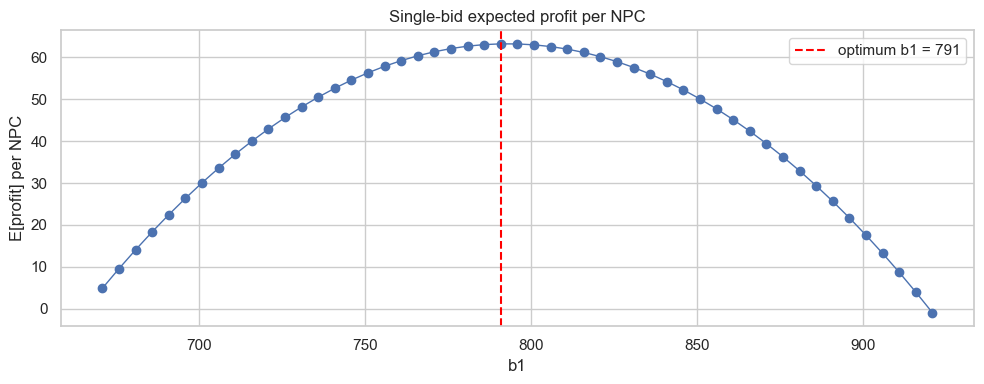

In [2]:
rows = []
for b1 in B1_GRID:
    k1 = int((RESERVES < b1).sum())
    e = (k1 / N_RESERVES) * (SELL_PRICE - b1)
    rows.append({"b1": int(b1), "k1": k1, "E": e})
single_bid = pd.DataFrame(rows)
opt = single_bid.loc[single_bid["E"].idxmax()]
print(f"optimal single-bid b1 = {int(opt['b1'])}  k1 = {int(opt['k1'])}  E = {opt['E']:.4f}")

# sanity: matches the closed-form
assert int(opt["b1"]) == 791
assert int(opt["k1"]) == 25
assert abs(opt["E"] - 25 * 129 / N_RESERVES) < 1e-9

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(single_bid["b1"], single_bid["E"], marker="o", lw=1)
ax.axvline(opt["b1"], color="red", linestyle="--", label=f"optimum b1 = {int(opt['b1'])}")
ax.set_xlabel("b1"); ax.set_ylabel("E[profit] per NPC")
ax.set_title("Single-bid expected profit per NPC")
ax.legend(); plt.tight_layout(); plt.show()

### Two-bid extension

With both `b1 < b2`:

$$ E[\text{profit/NPC}] = \frac{k_1}{51}(920 - b_1) + \frac{k_2 - k_1}{51}\cdot \pi_{b_2} $$

where

$$ \pi_{b_2} = \begin{cases} 920 - b_2 & b_2 > \overline{b_2} \\ \dfrac{(920 - \overline{b_2})^3}{(920 - b_2)^2} & b_2 \le \overline{b_2} \end{cases} $$

Stages II and III explore how the optimum responds to different assumptions about $\overline{b_2}$.